In [1]:
"""Hydrangea demo: session EDA, then state-fitting EDA.

Runs from the notebook. `# %%` marks each cell boundary — split there.

The package root is discovered by walking up from the working directory, so
this works whether the notebook is launched from the repo root or from
Hydrangea_demo/, locally or on the cloud box where the repo lives at
/notebooks/CumulantDynamicsGuiltByAssociation. The data mount defaults to
/storage/dandi_downloads and can be overridden with HYDRANGEA_DATA_DIR.

Cells:
    1. setup and dataset inventory
    2. build the session: load, epoch, derived behaviour, object, channels
    3. spiking + behaviour EDA          <- judge epoch / units / channels / coverage
    4. normalize                        <- judge bin size and normalization method
    5. global embedding
    6. folds and the HMM sweep
    7. HMM report
    8. save, reload, summarize
"""

# %% ==========================================================================
# CELL 1 — setup and dataset inventory
# =============================================================================
# pynapple's Folder API walks the subject/session tree, so the inventory only
# has to parse identifiers out of the BIDS-style filenames:
#     sub-M01_ses-20240313T100000_behavior+ecephys.nwb
#     ^^^^^^^ ^^^^^^^^^^^^^^^^^^^ ^^^^^^^^^^^^^^^^^^
#     subject session             modalities
# Paths are shown relative to the data mount; the mount itself is printed once.

import os
import re
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import pynapple as nap


def find_package_root(start):
    """Walk up from `start` looking for the hybrid_dynamics_core package."""
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "hybrid_dynamics_core").is_dir():
            return candidate
        nested = candidate / "Hydrangea_demo"
        if (nested / "hybrid_dynamics_core").is_dir():
            return nested
    return start


PACKAGE_ROOT = find_package_root(Path.cwd())
if str(PACKAGE_ROOT) not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT))

from hybrid_dynamics_core.base import HybridDynamicsAnalysis  # noqa: E402
from hybrid_dynamics_core.spiking_and_behaviour_eda import (  # noqa: E402
    compute_speed_from_position,
)

DOWNLOAD_DIR = Path(os.environ.get("HYDRANGEA_DATA_DIR", "/storage/dandi_downloads")).resolve()
MODEL_DIR = DOWNLOAD_DIR / "hydrangea_models"
DANDISET_ID = "001695"
VERSION_ID = "0.260319.2023"

# Session to analyze. Set either to None to take the first behaviour recording.
SUBJECT = "M01"
SESSION = "20240313T100000"

BIN_SIZE_S = 0.050
EDA_WINDOW_S = 60
N_UNITS_PER_GROUP = 5

if DOWNLOAD_DIR.is_dir():
    MODEL_DIR.mkdir(parents=True, exist_ok=True)


def parse_session_name(nwb_path, root):
    """Subject, session, date, time, and modalities from an NWB filename."""
    nwb_path = Path(nwb_path)
    stem = nwb_path.stem

    subject = re.search(r"(?:^|_)sub-([^_]+)", stem)
    session = re.search(r"(?:^|_)ses-([^_]+)", stem)
    subject = subject.group(1) if subject else nwb_path.parent.name.replace("sub-", "")
    session = session.group(1) if session else "unknown"

    date, clock = None, None
    if "T" in session:
        raw_date, raw_time = session.split("T", 1)
        if len(raw_date) == 8 and raw_date.isdigit():
            date = f"{raw_date[:4]}-{raw_date[4:6]}-{raw_date[6:]}"
        if len(raw_time) >= 6 and raw_time[:6].isdigit():
            clock = f"{raw_time[:2]}:{raw_time[2:4]}:{raw_time[4:6]}"

    modalities = stem.split("_")[-1].split("+")
    return {
        "subject": subject,
        "session": session,
        "date": date,
        "time": clock,
        "modalities": "+".join(modalities),
        "has_behavior": "behavior" in modalities,
        "size_mb": round(nwb_path.stat().st_size / 1e6, 1),
        "file": str(nwb_path.relative_to(root)),
    }


def session_inventory(root):
    """Table of every NWB recording under the data mount."""
    rows = [parse_session_name(p, root) for p in sorted(Path(root).rglob("*.nwb"))]
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values(["subject", "session"]).reset_index(drop=True)


project = nap.load_folder(str(DOWNLOAD_DIR))
inventory = session_inventory(DOWNLOAD_DIR)

print("Package root:", PACKAGE_ROOT)
print("Data mount:  ", DOWNLOAD_DIR)
print(
    f"{len(inventory)} recordings | {inventory['subject'].nunique()} subjects | "
    f"{inventory['size_mb'].sum() / 1000:.1f} GB"
)
inventory


Package root: /notebooks/CumulantDynamicsGuiltByAssociation/Hydrangea_demo
Data mount:   /storage/dandi_downloads
16 recordings | 4 subjects | 2.6 GB


,subject,session,date,time,modalities,has_behavior,size_mb,file
0,M01,20240308T100000,2024-03-08,10:00:00,ecephys,False,70.7,sub-M01/sub-M01_ses-20240308T100000_ecephys.nwb
1,M01,20240312T100000,2024-03-12,10:00:00,behavior+ecephys,True,187.4,sub-M01/sub-M01_ses-20240312T100000_behavior+e...
2,M01,20240313T100000,2024-03-13,10:00:00,behavior+ecephys,True,125.8,sub-M01/sub-M01_ses-20240313T100000_behavior+e...
3,M01,20240314T100000,2024-03-14,10:00:00,behavior+ecephys,True,134.6,sub-M01/sub-M01_ses-20240314T100000_behavior+e...
4,M01,20240318T100000,2024-03-18,10:00:00,behavior+ecephys,True,190.0,sub-M01/sub-M01_ses-20240318T100000_behavior+e...
5,M02,20240312T100000,2024-03-12,10:00:00,behavior+ecephys,True,61.3,sub-M02/sub-M02_ses-20240312T100000_behavior+e...
6,M02,20240313T100000,2024-03-13,10:00:00,behavior+ecephys,True,98.3,sub-M02/sub-M02_ses-20240313T100000_behavior+e...
7,M02,20240314T100000,2024-03-14,10:00:00,behavior+ecephys,True,121.2,sub-M02/sub-M02_ses-20240314T100000_behavior+e...
8,M02,20240318T100000,2024-03-18,10:00:00,behavior+ecephys,True,112.5,sub-M02/sub-M02_ses-20240318T100000_behavior+e...
9,M03,20240621T100000,2024-06-21,10:00:00,behavior+ecephys,True,199.8,sub-M03/sub-M03_ses-20240621T100000_behavior+e...


In [2]:
project.view

📂 dandi_downloads
├── 📂 hydrangea_models
├── 📂 sub-M01
│   ├── sub-M01_ses-20240312T100000_behavior+ecephys    |        NWB file
│   ├── sub-M01_ses-20240313T100000_behavior+ecephys    |        NWB file
│   ├── sub-M01_ses-20240308T100000_ecephys     |        NWB file
│   ├── sub-M01_ses-20240318T100000_behavior+ecephys    |        NWB file
│   └── sub-M01_ses-20240314T100000_behavior+ecephys    |        NWB file
├── 📂 sub-M02
│   ├── sub-M02_ses-20240318T100000_behavior+ecephys    |        NWB file
│   ├── sub-M02_ses-20240312T100000_behavior+ecephys    |        NWB file
│   ├── sub-M02_ses-20240314T100000_behavior+ecephys    |        NWB file
│   └── sub-M02_ses-20240313T100000_behavior+ecephys    |        NWB file
├── 📂 sub-M03
│   ├── sub-M03_ses-20240621T100000_behavior+ecephys    |        NWB file
│   ├── sub-M03_ses-20240623T100000_behavior+ecephys    |        NWB file
│   ├── sub-M03_ses-20240624T100000_behavior+ecephys    |        NWB file
│   └── sub-M03_ses-20240622T100000_behavior+ecephys    |        NWB file
└── 📂 sub-M05
    ├── sub-M05_ses-20240730T100000_behavior+ecephys    |        NWB file
    ├── sub-M05_ses-20240729T100000_behavior+ecephys    |        NWB file
    └── sub-M05_ses-20240731T100000_behavior+ecephys    |        NWB file

In [4]:
# %% ==========================================================================
# CELL 2 — build the session
# =============================================================================
# Everything needed before any modelling decision, in four steps:
#
#   2a  load the chosen recording
#   2b  restrict to the analysis epoch (the position-tracked span)
#   2c  derive behaviour the archive does not ship (running speed)
#   2d  build the analysis object and register its behaviour channels
#
# Step 2c stays out of the object on purpose: how a derived channel is built
# (which columns, how much smoothing) is a per-dataset decision, whereas the
# object only needs the finished signal plus its sampling rate.

cell_started = time.perf_counter()

# --- 2a. load the recording ------------------------------------------------
print("=" * 72)
print("2a. load recording")
print("=" * 72)

candidates = inventory[inventory["has_behavior"]]
if SUBJECT is not None:
    candidates = candidates[candidates["subject"] == SUBJECT]
if SESSION is not None:
    candidates = candidates[candidates["session"] == SESSION]
if len(candidates) == 0:
    raise FileNotFoundError(f"No behaviour recording for subject={SUBJECT}, session={SESSION}")

session_row = candidates.iloc[0]
session_nwb_path = (DOWNLOAD_DIR / session_row["file"]).resolve()

t0 = time.perf_counter()
session_nwb = nap.load_file(str(session_nwb_path))
spike_group = session_nwb["units"]
position_xy = session_nwb["Position"]
print(f"loaded {session_row['file']} in {time.perf_counter() - t0:.1f}s")
print(f"NWB keys: {list(session_nwb.keys())}")
print(f"{len(spike_group)} units recorded")

# --- 2b. restrict to the analysis epoch ------------------------------------
print("\n" + "=" * 72)
print("2b. analysis epoch")
print("=" * 72)
# States are only interpretable where behaviour is observed, so the pipeline is
# restricted to the position-tracked span. Everything before and after it
# (pre-task rest, post-task handling) is discarded here rather than filtered
# later, which keeps the observation matrix and the behaviour on one clock.

recording_start = float(min(spike_group[u].index[0] for u in spike_group.index if len(spike_group[u])))
recording_end = float(max(spike_group[u].index[-1] for u in spike_group.index if len(spike_group[u])))
maze_start = float(position_xy.index[0])
maze_end = float(position_xy.index[-1])
maze_ep = nap.IntervalSet(start=maze_start, end=maze_end)
spike_group_maze = spike_group.restrict(maze_ep)

recording_s = recording_end - recording_start
maze_s = maze_end - maze_start
print(f"recording span : {recording_start:8.1f} - {recording_end:8.1f}s  ({recording_s / 60:.1f} min)")
print(f"maze epoch     : {maze_start:8.1f} - {maze_end:8.1f}s  ({maze_s / 60:.1f} min)")
print(
    f"discarding {(recording_s - maze_s) / 60:.1f} min "
    f"({100 * (1 - maze_s / recording_s):.1f}% of the recording) outside the tracked span"
)
print(f"units before/after restriction: {len(spike_group)} / {len(spike_group_maze)}")

# --- 2c. derive running speed ----------------------------------------------
print("\n" + "=" * 72)
print("2c. derived behaviour")
print("=" * 72)

speed_t, speed_vals = compute_speed_from_position(
    position_xy, columns=("x", "y"), smooth_window_s=0.25
)
print(
    f"running speed: {len(speed_t)} samples @ {1 / np.median(np.diff(speed_t)):.1f} Hz | "
    f"median {np.median(speed_vals):.2f} cm/s, max {speed_vals.max():.1f} cm/s"
)

# --- 2d. build the object and register behaviour ---------------------------
print("\n" + "=" * 72)
print("2d. analysis object")
print("=" * 72)
# Unit metadata (region, cell type, anything else on the TsGroup) is read off
# the spike group automatically and carried through unit filtering. Trial,
# condition, and region tables are optional and dataset-specific.

trials = None
try:
    trials = session_nwb["trials"]
except Exception:
    print("no trials table in this NWB")

hybdyn = HybridDynamicsAnalysis(
    spike_group=spike_group_maze,
    bin_size_s=BIN_SIZE_S,
    maze_epoch=maze_ep,
    trial_table=trials,  # an IntervalSet is coerced to a start/end table
    session_id=session_nwb_path.stem,
    mouse_id=session_row["subject"],
    embedding_method="pca",
    state_discovery_method="gaussian_hmm",
    random_state=0,
    report="selected",
)

# Continuous channels carry a sampling-rate descriptor (inferred from the
# timestamps here). Discrete channels carry a time interval and optional
# subtypes. Both project onto the observation bins later.
hybdyn.add_continuous_behavior(
    "position",
    time=position_xy.index.values,
    values=np.column_stack([position_xy["x"].values, position_xy["y"].values]),
    columns=["x", "y"],
    units="cm",
    description="tracked position on the maze",
)
hybdyn.add_continuous_behavior(
    "running_speed",
    time=speed_t,
    values=speed_vals,
    units="cm/s",
    color="k",
    description="derived from position, 0.25s boxcar",
)
hybdyn.add_events_from_interval_set(
    "maze_epoch", maze_ep, description="position-tracked span used for all fitting"
)
if trials is not None:
    hybdyn.add_events_from_interval_set("trials", trials, description="task trials")

print(
    f"object built: {len(hybdyn.continuous_behavior)} continuous channels, "
    f"{len(hybdyn.discrete_events)} event sets"
)
print(f"\ncell 2 complete in {time.perf_counter() - cell_started:.1f}s")



2a. load recording
loaded sub-M01/sub-M01_ses-20240313T100000_behavior+ecephys.nwb in 0.9s
NWB keys: ['units', 'SleepStates', 'Best_Ripple_channel_LFP_CA1', 'Speed', 'Position']
240 units recorded

2b. analysis epoch
recording span :      0.0 -  11188.8s  (186.5 min)
maze epoch     :   4892.8 -   6521.2s  (27.1 min)
discarding 159.3 min (85.4% of the recording) outside the tracked span
units before/after restriction: 240 / 240

2c. derived behaviour
running speed: 40708 samples @ 25.0 Hz | median 1.19 cm/s, max 52.7 cm/s

2d. analysis object
no trials table in this NWB
object built: 2 continuous channels, 1 event sets

cell 2 complete in 0.9s


1. metadata tables
Metadata tables
------------------------------------
unit_metadata    rows=240    cols=14  rate, cell_type, cell_area, firing_rate, ab_ratio, burstIndex_Mizuseki2012, cv2, maxWaveformCh, troughToPeak, acg_tau_decay, acg_tau_rise, thetaModulationIndex, x_position_probe, y_position_probe
trial_table      rows=0      cols=0   -
condition_table  rows=0      cols=0   -
region_table     rows=0      cols=0   -
region column:    cell_area
cell-type column: cell_type

2. unit inventory

Unit counts (region x cell_type, with Total):
cell_type  Total  Narrow Interneuron  Pyramidal Cell  Wide Interneuron
region                                                                
CA1          103                  15              85                 3
CA3           83                  55              27                 1
RSC           54                  23              15                16


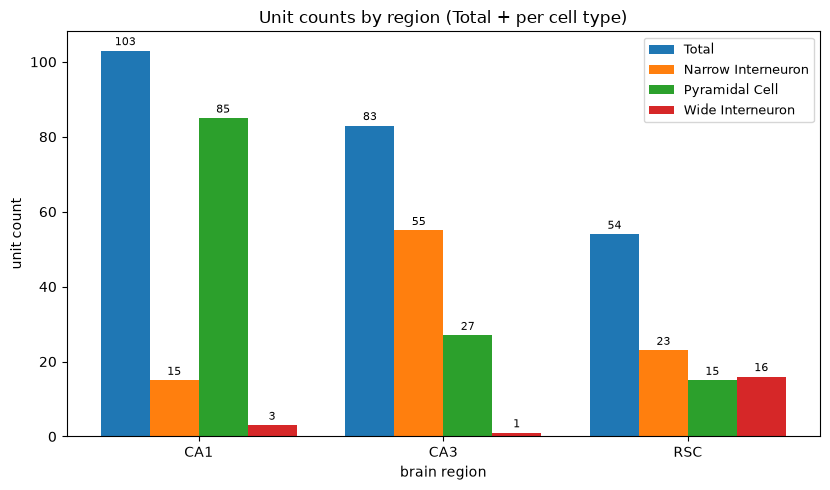


3. behaviour channels

Registered behaviour channels:
                     kind  n_dims  n_samples_or_events  sampling_rate_hz  \
name                                                                       
position       continuous       2                40708         25.018764   
running_speed  continuous       1                40708         25.018764   
maze_epoch       discrete       1                    1               NaN   

               t_start_s      t_end_s subtypes units  \
name                                                   
position       4892.8469  6521.175133     None    cm   
running_speed  4892.8469  6521.175133     None  cm/s   
maze_epoch     4892.8469  6521.175133     None     s   

                                              description  
name                                                       
position                     tracked position on the maze  
running_speed         derived from position, 0.25s boxcar  
maze_epoch     position-tracked span used f

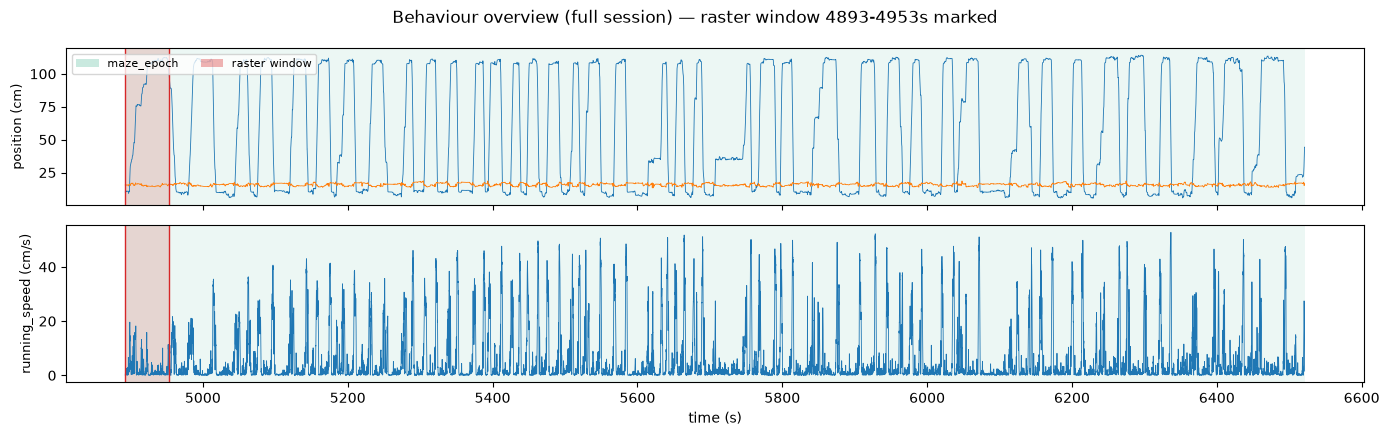

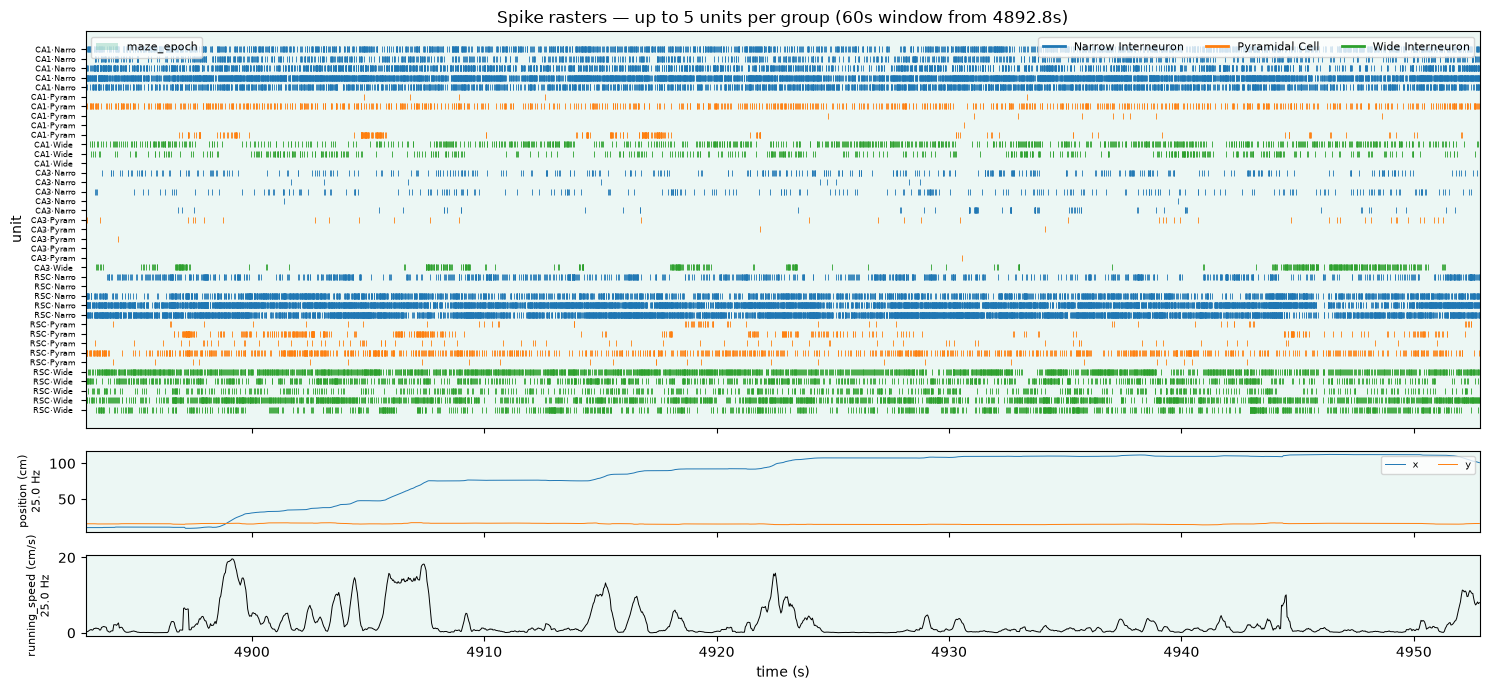


EDA complete in 1.0s


In [5]:
# %% ==========================================================================
# CELL 3 — spiking + behaviour EDA
# =============================================================================
# Human judgement: are the epoch, the unit sample, and the behavioural channels
# sensible, and does each channel actually cover the bins it will be aligned to?
#
# Prints, in order: metadata tables, unit inventory, behaviour channels,
# behaviour coverage on 50 ms bins. Then plots the unit inventory, the
# full-session behaviour overview with the raster window marked on it, and the
# raster for that window. Coverage is computed here rather than after
# normalization because behaviour binning does not depend on the spikes.

hybdyn.spiking_behavior_report(
    window_s=EDA_WINDOW_S,
    n_units_per_group=N_UNITS_PER_GROUP,
    show=True,
)


/notebooks/CumulantDynamicsGuiltByAssociation/Hydrangea_demo/hybrid_dynamics_core/normalization.py:87: UserWarning: Dropped 3 neurons with no spikes in analyzed time interval. Per-region dropped counts -> CA1:1, CA3:2.
  warnings.warn(msg)


method             proportion_then_zscore
bin_size_s                           0.05
n_bins                              32567
n_units                               237
duration_s                         1628.4
duration_min                        27.14
total_spikes                      2483139
frac_empty_bins                    0.8336
median_rate_hz                      0.622
min_rate_hz                        0.0006
max_rate_hz                        78.532


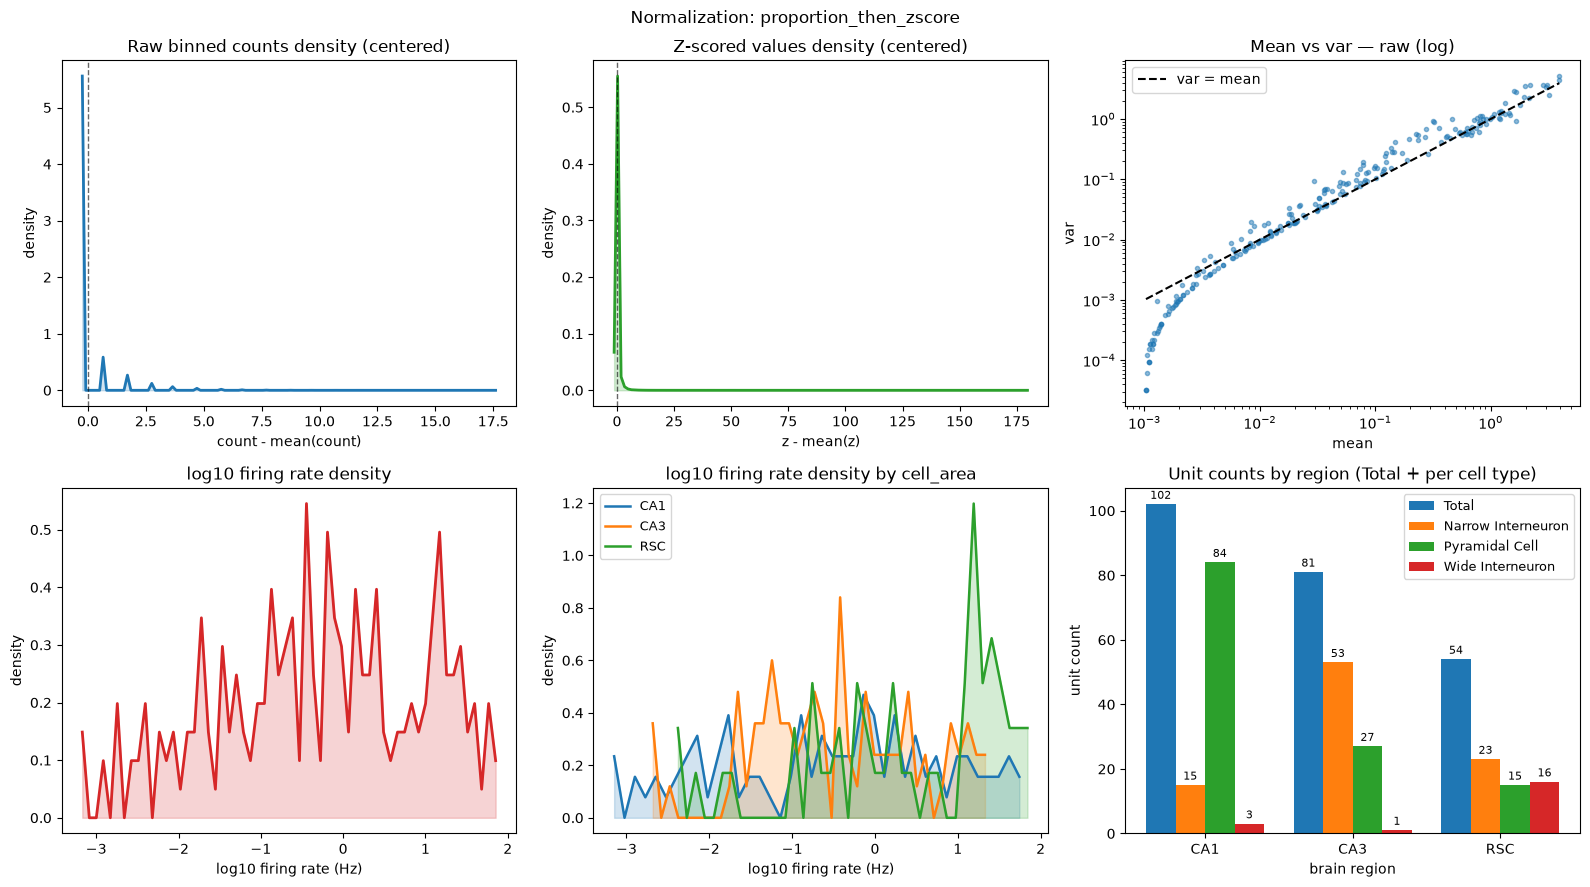


Behaviour on the observation bins:


,kind,bins_with_data,frac_bins_covered,seconds_covered
channel,,,,
x,continuous,32567,1.0,1628.4
y,continuous,32567,1.0,1628.4
running_speed,continuous,32567,1.0,1628.4
maze_epoch.occupancy,event occupancy,32567,1.0,1628.4
maze_epoch.count,event onsets,1,0.0,0.1


In [6]:
# %% ==========================================================================
# CELL 4 — normalization
# =============================================================================
# Human judgement, and worth dwelling on: is the bin size and normalization
# method appropriate for this firing-rate distribution?
#
# `proportion_zscore` divides each unit's binned counts by its total spike
# count before z-scoring, so a 30 Hz interneuron and a 0.2 Hz pyramidal cell
# contribute comparably to the observation matrix instead of the fast cells
# dominating the covariance the PCA and HMM will see.
#
# Set log_scale=False on the report to see the rate and mean-variance panels on
# linear axes — log spreads out the near-silent tail, linear shows the
# high-rate units in proportion.

hybdyn.normalize(method="proportion_zscore", zscore=True, restrict_to_epoch=True)
hybdyn.normalization_report(show=True, log_scale=True)

# Behaviour re-aligned to the final observation bins. Coverage should match what
# cell 3 reported; if it does not, the epoch or the bin size moved.
behavior_bins = hybdyn.align_behavior_to_bins()
print("\nBehaviour on the observation bins:")
hybdyn.behavior_coverage(aligned=behavior_bins)


PCA: 10 components, 13.4% of variance retained (PC1 2.5%)


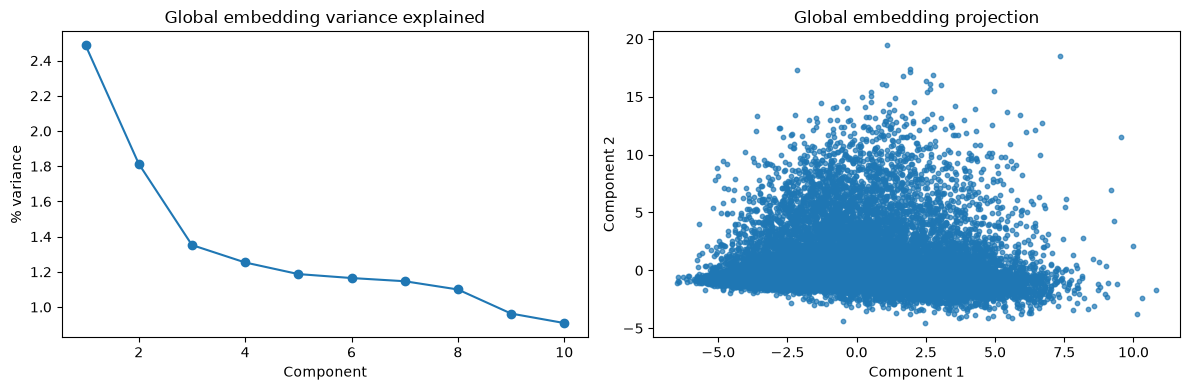

In [7]:
# %% ==========================================================================
# CELL 5 — global embedding
# =============================================================================
# The session-wide PCA that the HMM observes.

hybdyn.global_embedding(method="pca", n_components=10, whiten=False, standardize=True)
cumulative = np.cumsum(hybdyn.global_embedding_variance_ratio)
print(
    f"PCA: {hybdyn.global_embedding_scores.shape[1]} components, "
    f"{100 * cumulative[-1]:.1f}% of variance retained "
    f"(PC1 {100 * hybdyn.global_embedding_variance_ratio[0]:.1f}%)"
)
hybdyn.report_embeddings(show=True)



In [8]:
# %% ==========================================================================
# CELL 6 — folds and the HMM sweep
# =============================================================================
# This is the slow step: K * (1 + k_fold) EM runs. `show_progress` prints which
# K and fold is running, how long each took, whether EM converged, and a rolling
# estimate of time remaining. `verbose` is hmmlearn's own per-EM-iteration
# monitor — leave it off unless a single fit refuses to converge.

hybdyn.build_folds(
    k_fold=5,
    fold_strategy="temporal_segments",
    shuffle_within_segments=True,
    seed=0,
)
print(f"{len(hybdyn.fold_idx)} folds, {len(hybdyn.fold_idx[0])} held-out bins each")

hybdyn.fit_states(
    n_states_min=2,
    n_states_max=10,
    k_fold=5,
    fold_strategy="temporal_segments",
    shuffle_within_segments=True,
    n_iter=100,
    covariance_type="diag",
    verbose=False,
    use_cv=True,
    show_progress=True,
    report="none",  # the full table is shown in cell 7
)



5 folds, 6513 held-out bins each
Fitting 9 models (K=2..10) on 32567 bins x 237 units | diag covariance | 5 CV folds -> 54 EM runs
  K=10  [1/9]
      full fit     47.3s   57 iter  converged       loglik=8,716,330
      fold 1/5    18.7s   23 iter  converged       held-out loglik=-10,955,543
      fold 2/5    47.0s   73 iter  converged       held-out loglik=-108,493,101


Model is not converging.  Current: 5149131.631242538 is not greater than 5149132.133978575. Delta is -0.5027360366657376


      fold 3/5    15.9s   21 iter  converged       held-out loglik=-40,413,308


Model is not converging.  Current: 6106492.1351933945 is not greater than 6106492.176120053. Delta is -0.04092665854841471


      fold 4/5    19.9s   26 iter  converged       held-out loglik=-43,531,694
      fold 5/5    22.9s   30 iter  converged       held-out loglik=-54,680,441
      K=10 done in 171.6s | median CV loglik=-43,531,694 | elapsed 2.9 min, ~23.1 min left
  K=9   [2/9]
      full fit     33.4s   48 iter  converged       loglik=6,758,889


...

Model is not converging.  Current: 96771.27471866993 is not greater than 96810.97715532246. Delta is -39.702436652529286


      fold 5/5     5.3s   19 iter  converged       held-out loglik=-4,333,497,196
      K=3 done in 54.8s | median CV loglik=-2,384,017,289 | elapsed 14.8 min, ~1.9 min left
  K=2   [9/9]
      full fit      3.5s   11 iter  converged       loglik=-1,669,446
      fold 1/5     4.6s   10 iter  converged       held-out loglik=-487,539,542
      fold 2/5     2.9s   11 iter  converged       held-out loglik=-8,966,093,361


Model is not converging.  Current: -1865315.6251502393 is not greater than -1865315.4314541344. Delta is -0.19369610492140055


      fold 3/5     2.8s   11 iter  converged       held-out loglik=-9,300,273,622
      fold 4/5     2.6s   10 iter  converged       held-out loglik=-1,215,557,224
      fold 5/5     2.7s   10 iter  converged       held-out loglik=-8,970,621,938
      K=2 done in 19.0s | median CV loglik=-8,966,093,361 | elapsed 15.1 min, ~0.0 min left

Sweep finished in 15.1 min. Best K=10 by median CV log-likelihood.


,n_params,loglik,loglik_per_bin,AIC,BIC,mean_cv_loglik,median_cv_loglik,std_cv_loglik,min_cv_loglik,max_cv_loglik,converged,n_iter_run,fit_seconds,cv_seconds,total_seconds,cv_fold_loglik
n_states,,,,,,,,,,,,,,,,
2,951,-1.669446e+06,-51.261903,3.340795e+06,3.348775e+06,-5.788017e+09,-8.966093e+09,4.038998e+09,-9.300274e+09,-4.875395e+08,True,11,3.502018,15.515829,19.017847,"[-487539542.2452758, -8966093361.104208, -9300..."
3,1430,2.627974e+06,80.694390,-5.253088e+06,-5.241089e+06,-2.204834e+09,-2.384017e+09,1.604312e+09,-4.333497e+09,-2.794428e+08,True,34,9.222677,45.621543,54.844221,"[-509362808.6776975, -3517851404.9172387, -238..."
4,1911,3.233548e+06,99.289095,-6.463274e+06,-6.447239e+06,-1.007234e+09,-6.490130e+08,7.928887e+08,-2.283787e+09,-2.236777e+08,True,40,14.327948,42.150619,56.478567,"[-322427113.75721115, -2283787090.595701, -649..."
5,2394,5.987379e+06,183.848050,-1.196997e+07,-1.194988e+07,-6.698528e+08,-2.523711e+08,7.018070e+08,-1.532500e+09,-1.051397e+07,True,22,12.594415,67.641504,80.235920,"[-10513973.862829665, -1532499964.0759385, -39..."
6,2879,7.285588e+06,223.710754,-1.456542e+07,-1.454126e+07,-2.405368e+08,-5.675711e+07,3.775847e+08,-9.956007e+08,-4.045140e+07,True,18,15.011377,72.460038,87.471414,"[-40451403.9733572, -995600736.8388475, -56757..."
7,3366,4.574388e+06,140.460848,-9.142045e+06,-9.113801e+06,-1.342765e+08,-8.648326e+07,1.070865e+08,-3.249497e+08,-2.742969e+07,True,54,29.577162,78.805374,108.382536,"[-58676363.43345269, -173843321.82506374, -324..."
8,3855,6.003170e+06,184.332922,-1.199863e+07,-1.196628e+07,-1.322364e+08,-9.244978e+07,1.061887e+08,-3.220032e+08,-3.864921e+07,True,53,40.034640,120.962062,160.996702,"[-168990545.29153344, -322003200.1864753, -924..."
9,4346,6.758889e+06,207.537961,-1.350909e+07,-1.347262e+07,-8.989906e+07,-1.062462e+08,3.865188e+07,-1.312415e+08,-2.266119e+07,True,48,33.373372,126.862940,160.236312,"[-22661185.0103084, -116201063.27633655, -1312..."
10,4839,8.716330e+06,267.643027,-1.742298e+07,-1.738238e+07,-5.161482e+07,-4.353169e+07,3.190149e+07,-1.084931e+08,-1.095554e+07,True,57,47.252605,124.364056,171.616661,"[-10955543.000678608, -108493101.00554158, -40..."


Models ranked by median CV log-likelihood:
          n_params  loglik_per_bin           AIC           BIC  \
n_states                                                         
10            4839         267.643 -1.742298e+07 -1.738238e+07   
6             2879         223.711 -1.456542e+07 -1.454126e+07   
7             3366         140.461 -9.142045e+06 -9.113801e+06   
8             3855         184.333 -1.199863e+07 -1.196628e+07   
9             4346         207.538 -1.350909e+07 -1.347262e+07   
5             2394         183.848 -1.196997e+07 -1.194988e+07   
4             1911          99.289 -6.463274e+06 -6.447239e+06   
3             1430          80.694 -5.253088e+06 -5.241089e+06   
2              951         -51.262  3.340795e+06  3.348775e+06   

          mean_cv_loglik  median_cv_loglik  std_cv_loglik  min_cv_loglik  \
n_states                                                                   
10         -5.161482e+07     -4.353169e+07   3.190149e+07  -1.084931e+08   
6 

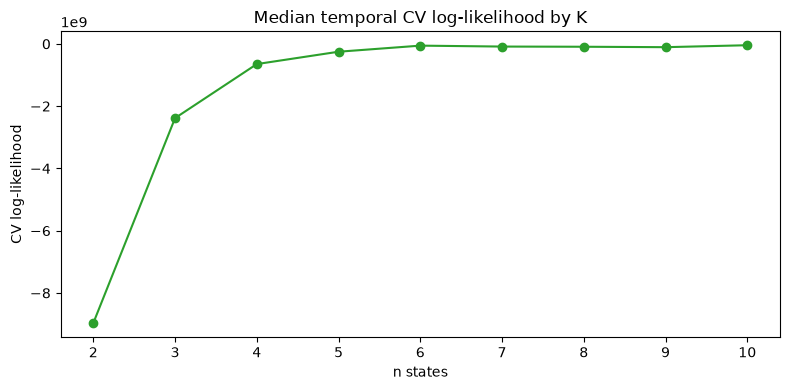

,n_params,loglik_per_bin,AIC,BIC,mean_cv_loglik,median_cv_loglik,std_cv_loglik,min_cv_loglik,max_cv_loglik,converged,n_iter_run,total_seconds
n_states,,,,,,,,,,,,
10,4839,267.643,-1.742298e+07,-1.738238e+07,-5.161482e+07,-4.353169e+07,3.190149e+07,-1.084931e+08,-1.095554e+07,True,57,171.617
6,2879,223.711,-1.456542e+07,-1.454126e+07,-2.405368e+08,-5.675711e+07,3.775847e+08,-9.956007e+08,-4.045140e+07,True,18,87.471
7,3366,140.461,-9.142045e+06,-9.113801e+06,-1.342765e+08,-8.648326e+07,1.070865e+08,-3.249497e+08,-2.742969e+07,True,54,108.383
8,3855,184.333,-1.199863e+07,-1.196628e+07,-1.322364e+08,-9.244978e+07,1.061887e+08,-3.220032e+08,-3.864921e+07,True,53,160.997
9,4346,207.538,-1.350909e+07,-1.347262e+07,-8.989906e+07,-1.062462e+08,3.865188e+07,-1.312415e+08,-2.266119e+07,True,48,160.236
5,2394,183.848,-1.196997e+07,-1.194988e+07,-6.698528e+08,-2.523711e+08,7.018070e+08,-1.532500e+09,-1.051397e+07,True,22,80.236
4,1911,99.289,-6.463274e+06,-6.447239e+06,-1.007234e+09,-6.490130e+08,7.928887e+08,-2.283787e+09,-2.236777e+08,True,40,56.479
3,1430,80.694,-5.253088e+06,-5.241089e+06,-2.204834e+09,-2.384017e+09,1.604312e+09,-4.333497e+09,-2.794428e+08,True,34,54.844
2,951,-51.262,3.340795e+06,3.348775e+06,-5.788017e+09,-8.966093e+09,4.038998e+09,-9.300274e+09,-4.875395e+08,True,11,19.018


In [9]:
# %% ==========================================================================
# CELL 7 — HMM report
# =============================================================================
# Human judgement: inspect the ranked scores and choose a working K. The table
# carries the CV spread (mean/median/std/min/max across folds), per-bin
# log-likelihood so K values are comparable, EM convergence, and fit time.

hybdyn.hmm_report(report="selected")
# hybdyn.hmm_report(report="full")

# Optional next step: local embedding inside one discovered state.
# hybdyn.local_embedding(state_labels=hybdyn.state_labels_, state_value=0, method="pca", label="state_0")
# hybdyn.report_embeddings(scope="local", label="state_0", show=True)

hybdyn.hmm_score_table(sort_by="median_cv_loglik")



In [ ]:
# %% ==========================================================================
# CELL 7 — HMM report
# =============================================================================
# Human judgement: inspect the ranked scores and choose a working K. The table
# carries the CV spread (mean/median/std/min/max across folds), per-bin
# log-likelihood so K values are comparable, EM convergence, and fit time.

hybdyn.hmm_report(report="selected")
# hybdyn.hmm_report(report="full")

# Optional next step: local embedding inside one discovered state.
# hybdyn.local_embedding(state_labels=hybdyn.state_labels_, state_value=0, method="pca", label="state_0")
# hybdyn.report_embeddings(scope="local", label="state_0", show=True)

hybdyn.hmm_score_table(sort_by="median_cv_loglik")


# %% ==========================================================================
# CELL 8 — save, reload, summarize
# =============================================================================

saved_model_path = MODEL_DIR / f"{session_nwb_path.stem}_best_hmm.pkl"
hybdyn.save_hmm_model(saved_model_path)
reloaded_artifact = hybdyn.load_hmm_model(saved_model_path)

print("Saved model:", saved_model_path.name)
print("Reloaded model states:", reloaded_artifact["n_states"])
print("Best K:", hybdyn.best_k, "| models fit:", len(hybdyn.hmm_models))
print()
hybdyn.describe(as_text=True)
hybdyn.timing_summary(as_text=True)
